# Testing pose estimation

In [35]:
import torch

print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.9.1+cu126 12.6 True
NVIDIA GeForce RTX 4070 Laptop GPU


In [36]:
from pathlib import Path

import cv2
import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
from ultralytics import YOLO
from aitraf.utils import get_video_rotation_deg

CLIPS_DIR = Path("../data/clips")
YOLO_WEIGHTS = Path("../models/yolo11n-pose.pt")

CLIP_INDEX = 3
FRAME_INDEX = 100

#### Load video

In [37]:
clip_path = sorted(CLIPS_DIR.iterdir())[CLIP_INDEX]

clip_path

PosixPath('../data/clips/25-10-31 19-46-26 5688-00.00.46.631-00.00.52.733-seg04.mp4')

#### Extract a frame

In [38]:
# Load selected frame from the local video
frame_rgb = iio.imread(clip_path, index=FRAME_INDEX)
frame_rgb = np.rot90(frame_rgb, k=get_video_rotation_deg(clip_path) // 90)
frame_bgr = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
print(f"Loaded frame {FRAME_INDEX} from {clip_path.name}")

Loaded frame 100 from 25-10-31 19-46-26 5688-00.00.46.631-00.00.52.733-seg04.mp4


In [39]:
iio.immeta(str(clip_path), plugin="pyav")

{'video_format': 'yuv420p10le',
 'codec': 'hevc',
 'long_codec': 'HEVC (High Efficiency Video Coding)',
 'profile': 'Main 10',
 'fps': 30.0,
 'duration': 7.1,
 'major_brand': 'isom',
 'minor_version': '512',
 'compatible_brands': 'isomdby1iso2mp41',
 'encoder': 'Lavf62.3.100',
 'language': 'und',
 'handler_name': 'VideoHandler',
 'vendor_id': '[0][0][0][0]'}

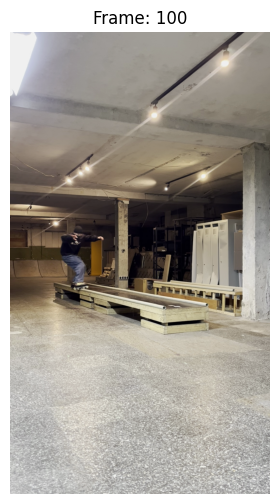

In [40]:
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
plt.title(f"Frame: {FRAME_INDEX}")
plt.axis("off")
plt.show()

#### Test on a frame

In [41]:
model = YOLO(YOLO_WEIGHTS)

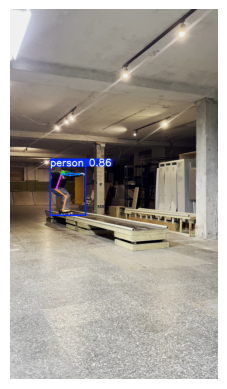

In [42]:
frame_pose = model.predict(
    source=frame_bgr, device="cuda", imgsz=640, conf=0.5, verbose=False, max_det=1
)

vis = frame_pose[0].plot()
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

#### Test on full video

In [43]:
results = model.predict(
    source=clip_path.as_posix(),
    device="cuda",
    imgsz=640,
    conf=0.5,
    save=True,
    verbose=False,
    max_det=1,
)

WARNING ⚠️ 
inference results will accumulate in RAM unless `stream=True` is passed, causing potential out-of-memory
errors for large sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Results saved to /workspace/runs/pose/predict12
